# If running this notebook on google colab, **change runtime type** and choose T4 gpu.

In [1]:
import copy
import torch
import sklearn
import numpy as np
import pandas as pd
from torch import nn
from tqdm.notebook import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt
# Test whether the notebook is running on google colab or not, and set the data path accordingly
import os
if os.getenv("COLAB_RELEASE_TAG") is None:
    DATA_IN_PATH = '../data'
else:
    DATA_IN_PATH = 'https://raw.githubusercontent.com/rguilcas/BCCR-ML-course/refs/heads/main/lecture_exercises/data'

# STEP 1 PREPROCESSING DATA
The first step of the machine learning pipeline is to load the data from a file. Here, our data is stored in the `dataset_energy.csv`. We use the `pandas` library to load the data.

In [3]:
df = pd.read_csv(f'{DATA_IN_PATH}/dataset_energy.csv', index_col=0)
df

,Pr,Tmax,Tmin,v_mean,v_max,Consumption Cabins and holiday properties,Consumption Household,Consumption Primary Industry,Consumption Secondary Industry,Consumption Tertiary Service,Consumption Total,hour,dayofyear,month,dayofweek
2020-12-31 23:00:00,0.0,0.6,-0.4,0.9,2.4,83301.548,565464.941,15941.561,1094799.611,281465.947,2040973.608,23,366,12,3
2021-01-01 00:00:00,0.0,-0.3,-0.6,0.2,1.0,81239.060,561738.679,15635.410,1099480.696,281856.955,2039950.800,0,1,1,4
2021-01-01 01:00:00,0.0,-0.4,-1.1,0.7,1.3,78309.658,552567.055,15568.727,1054455.916,282018.246,1982919.602,1,1,1,4
2021-01-01 02:00:00,0.0,-0.6,-1.2,0.6,0.8,75951.558,539974.014,15459.587,1049728.608,283190.286,1964304.053,2,1,1,4
2021-01-01 03:00:00,0.0,-1.0,-1.5,1.5,1.5,75057.689,530039.983,15537.723,1099942.882,284519.093,2005097.370,3,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-16 17:00:00,2.1,13.0,12.9,1.8,1.8,21527.503,368426.508,13442.023,863990.567,422169.360,1689555.961,17,259,9,1
2025-09-16 18:00:00,0.0,12.9,12.8,0.4,2.3,22074.614,382777.219,13315.455,843881.452,345811.055,1607859.795,18,259,9,1
2025-09-16 19:00:00,0.0,12.9,12.4,2.1,2.2,22004.477,381955.358,12774.351,826840.103,292443.352,1536017.641,19,259,9,1
2025-09-16 20:00:00,0.0,12.6,12.4,3.3,3.6,22002.303,362725.748,12505.712,818787.621,273220.806,1489242.190,20,259,9,1


Our dataset contains hourly values from 2020 to 2025.

Once the data is loaded, we need to turn the datasets into an ML friendly array. To do this, we choose the variables necessary for the analysis and then we transform them into numpy arrays.

In [4]:
X = df[['Pr','Tmin','v_mean','v_max']].values # X is the array containing the data we use to predict the result.
y = df[['Consumption Cabins and holiday properties']].values # y is the array representing the values we want to predict.

## **QUESTION 1**: Create train, validation and test datasets from `X` and `y`.

In [ ]:
X_train, X_valtest, y_train, y_valtest = ...
X_val, X_test, y_val, y_test = ...

Once we have made the split into train and test, we will transform the data using StandardScaler, which means we remove the mean and divide by the standard deviation.

## **QUESTION 2**: Transform `X` and `y` using `StandardScaler`. 
Remember, the scaler should only fit the train dataset.

In [ ]:
scaler_X = ...
scaler_y = ...

...
...

X_train = ...
X_val = ...
X_test = ...

y_train = ...
y_val = ...
y_test = ...

> **_CAREFUL:_**  **Pytorch does not work with numpy arrays**.
> 
> `X` and `y` datasets must be converted to tensor, which is a kind of array with additional properties.

In [7]:
X_train = torch.tensor(X_train, dtype=torch.float)
X_val = torch.tensor(X_val, dtype=torch.float)
X_test = torch.tensor(X_test, dtype=torch.float)

y_train = torch.tensor(y_train, dtype=torch.float)
y_val = torch.tensor(y_val, dtype=torch.float)
y_test = torch.tensor(y_test, dtype=torch.float)

> In addition, we will want to use, which is a specialized computing unit which allows for faster training. We will talk about it later in the session.
>
> To use the GPU, all data and models must **be** on the GPU. We send data around by using data.to(device).
> 
> We use a device called `cuda`, which corresponds to GPU built by the NVIDIA brand.

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu' # 'cuda' for nvidia gpus, 'mps' for mac or 'cpu' for cpu use
# If you are connected to the T4 GPU runtime on Google Colab, cuda should be available.
print(f"Using device: {device}")

X_train = X_train.to(device)
X_val = X_val.to(device)
X_test = X_test.to(device)

y_train = y_train.to(device)
y_val = y_val.to(device)
y_test = y_test.to(device)

Using device: cpu


# STEP 2: Define ML model and fit it to the data - Source file


There are multiple ways to define neural networks, but the standard one is to build a python class. It is usually better to have a separate python file, but for simplicity here, we create the class in the next cell.

In [9]:
class MultiLayerPerceptron3layers(nn.Module):
    def __init__(self, 
                 number_input_features=3, 
                 number_of_predictions=1):
        super().__init__()
        self.layer1 = nn.Linear(number_input_features, 16)
        self.layer2 = nn.Linear(16, 16)
        self.layer3 = nn.Linear(16, number_of_predictions)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

We also define helpful functions for training the model.

In [10]:


def training_one_batch(model, X_batch, y_batch, optimizer, loss_fn):
    # forward pass: compute model predictions and the loss
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, y_batch)      
    # backward pass: compute gradients to know how to change weights
    optimizer.zero_grad()
    loss.backward()
    # update weights
    optimizer.step()


def evaluation_one_epoch(model, X_val, y_val, loss_fn, 
                         loss_history, best_loss_value, best_weights):
    y_pred = model(X_val)
    loss_value = loss_fn(y_pred, y_val).detach()
    loss_value = float(loss_value)
    loss_history.append(loss_value)
    if loss_value < best_loss_value:
        best_loss_value = loss_value
        best_weights = copy.deepcopy(model.state_dict())
    return best_loss_value, best_weights
    

## Define hyperparameters for training
We can choose some parameters for training, including learning rate, batch size and the number of epochs. We will get back to that.

We also define an optimizer and a loss function, which is what allows to train the model.

In [11]:
n_features = 4
n_predictions = 1
model = MultiLayerPerceptron3layers(number_input_features=n_features, number_of_predictions=n_predictions)
model = model.to(device)


# training hyperparameters
n_epochs = 20  # number of epochs to run
batch_size = 256  # size of each batch
learning_rate = 0.001  # learning rate
index_where_batches_start = torch.arange(0, len(X_train), batch_size)

loss_fn = nn.MSELoss()  # mean square error
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

model

MultiLayerPerceptron3layers(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (layer3): Linear(in_features=16, out_features=1, bias=True)
)

# Train network
Training happens in different steps.

In [12]:
# We keep the weights and biases of the best model
best_loss_value = np.inf   # initialise to infinity
best_weights = None
loss_history = []

# training loop
for epoch in tqdm(range(n_epochs)):
    model.train()
    for start in index_where_batches_start:
    # Select the batch of data
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        training_one_batch(model, X_batch, y_batch, optimizer, loss_fn,)
    model.eval()
    best_loss_value, best_weights = evaluation_one_epoch(model, X_val, y_val, 
                                                         loss_fn, loss_history, 
                                                         best_loss_value, best_weights)

# restore model weights to the best model
model.load_state_dict(best_weights)
model = model.eval()


  0%|          | 0/20 [00:00<?, ?it/s]

###  Plot training history: verify that the loss function goes down

MSE: 0.27
RMSE: 0.52


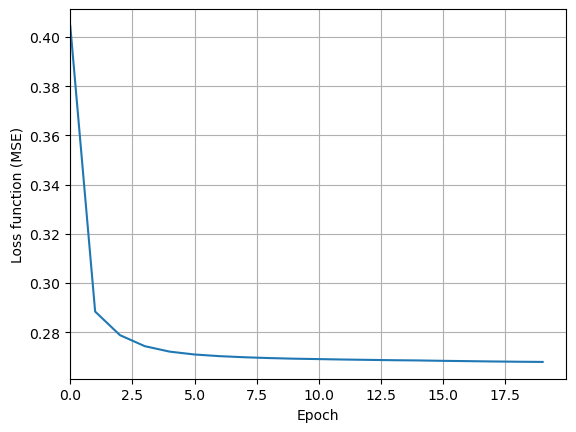

In [13]:
with torch.no_grad():
    best_pred = model(X_val).detach().cpu()


fix, ax = plt.subplots()
# ax.set_ylim(0,None)
print("MSE: %.2f" % best_loss_value)
print("RMSE: %.2f" % np.sqrt(best_loss_value))
ax.plot(loss_history)
ax.set_ylabel('Loss function (MSE)')
ax.set_xlabel('Epoch')
ax.set_xlim(0,None)
ax.grid()
plt.show()

# STEP 3: Make predictions and evaluate the model skill
Once the model is **trained** with the data, we can use it to make predictions.

## Step 3.1: Predict `y_val` from `X_val`
We predict the values of `y` from `X` based on the relation learned by the model. For neural networks with pytorch, there is no `model.predict` method. We only use `model(X)`

## **QUESTION 3**: Use the **validation data** to make predictions.

In [ ]:
y_val_predictions = ...

## Step 3.2: Plot the results and evaluate the model.
To visually evaluate the model, we plot the predicted `y` values against the true `y` values.


> This part is a bit confusing: pytorch tensors cannot be used directly for plots.
>
> Remember how we moved the data to the GPU in the first place? We have to move it back to the "normal" computer unit, the cpu.
> This is done by doing `data.to('cpu')`.
>
> Tensors also have additional properties that can only be stored on GPU and that differentiate them from normal numpy arrays. We also have to remove these additional properties before moving data back to the cpu by doing `data.detach()`.
>
> Overall, we need to write `data_cpu = data.detach().to('cpu')`
>
> Note that we also have to put the y_val back to the 'cpu'.

In [15]:
y_val_predictions_cpu = y_val_predictions.detach().to('cpu')
y_val_cpu = y_val.detach().to('cpu')

Once the predictions are ready to be used, we need to transform them back into the original dataspace.

## **QUESTION 4**: Use the `inverse_transform` to return `y_val_predictions_cpu` and `y_val_cpu` to the original data space.

In [ ]:
y_val_predictions_cpu = ...
y_val_cpu = ...

### Plot the predictions against the true data for the validation

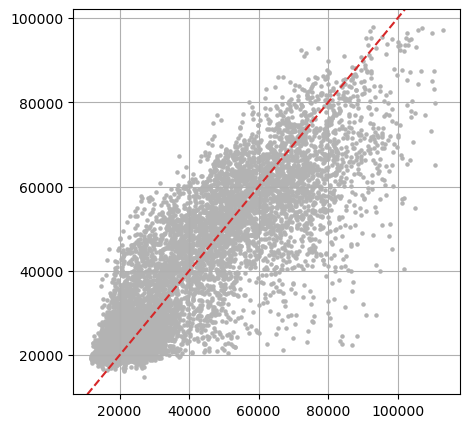

In [17]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_val_cpu,y_val_predictions_cpu, s=5, color='.7') 
ax.axline((y_val_cpu.mean(), y_val_cpu.mean()), slope=1, ls='--', color='tab:red')
ax.grid()

## **QUESTION 5**: Evaluate the model with the `r2_score` and the `root_mean_squared_error`.

In [ ]:
rmse = ...
r2_score = ...
print(f"RMSE: {rmse:.02f}")
print(f"R2: {r2_score:.02f}")

## **QUESTION 5**: compare the results with the linear regression
Usually, the neural networks will perform better for more complex relationship and non-linear tasks.

<div class="alert alert-block alert-warning">
<b>Note:</b> It is always great to compare neural network results with a much simpler linear model
</div>